# GrENE-Net phase-1 GEA replication on kMate — last-gen Manhattan grid

**Completed slice:** variant class (snp / smallindel / sv) x model (Kendall-tau /
LFMM K=16 / binomial regression), all at **gen9 (last-gen), bio1, WZA deg7-cap2000**
(the primary correction — deg-7 fits the SNP-count -> SD support curve best, the cap
removes tail extrapolation; see `../wza_investigation/`).

Each point is one LD block at its genomic position; y = -log10(WZA `Z_pVal`).
Red dashed = Bonferroni (0.05/n_blocks); orange dotted = BH q<0.05 critical value
(`q*k/m` for k BH-rejections; shown only where k>=1, so it is always <= Bonferroni).
The phase-1 headline **CAM5 / AT2G27030 (Chr2 ~11.53 Mb)** is circled at block
**2_1265** (the ~13-SNP signal) in snp/smallindel. The **sv** panels carry no CAM5
mark: no SV is called in the CAM5 block.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

WDIR = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/r2_gea_nonsnp/phase1_replication/results/wza"
CLASSES = ["snp", "smallindel", "sv"]      # rows
MODELS  = ["kendall", "lfmm", "binomial"]  # columns
REGIME  = "deg7cap2000"
CHROMS  = [f"Chr{i}" for i in range(1, 6)]
CAM5_BLOCK  = "2_1265"                     # CAM5 / AT2G27030 signal block (snp/indel; no SV)
Q_FLOOR     = 1e-16                         # floor WZA Z_pVal (matches build_significant_genes
                                            # --q-floor): it underflows float64 to 0 for extreme
                                            # high-LD blocks (e.g. Chr4 CRK 4_2519). -log10 -> 16.

def load(model, cls):
    f = f"{WDIR}/wza_{model}_{cls}_gen9_bio1_{REGIME}.csv"
    w = pd.read_csv(f).rename(columns={"index": "block"})
    w["block"] = w["block"].astype(str)
    w = w[w["Z_pVal"].notna() & w["chrom"].astype(str).isin(CHROMS)].copy()
    w["chrom"] = w["chrom"].astype(str)
    w["mlogp"] = -np.log10(w["Z_pVal"].clip(lower=Q_FLOOR))   # floored, not the old 1e-300
    return w

# shared cumulative genome x-axis from the union of all blocks (snp = densest)
allpos = pd.concat([load("kendall", c)[["chrom", "pos"]] for c in CLASSES])
chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
GAP = 5e6
offset, off = {}, 0.0
for c in CHROMS:
    offset[c] = off; off += chrom_max[c] + GAP
ticks = [offset[c] + chrom_max[c] / 2 for c in CHROMS]

# BH at level q -> (k rejections, critical-value threshold q*k/m).
# The q*k/m line is always >= Bonferroni's p-cutoff (never plots above Bonferroni);
# NaN when nothing is significant (k=0 -> no line drawn).
def bh_count_crit(p, q=0.05):
    v = np.sort(np.asarray(p, float)); m = len(v)
    ok = v <= q * np.arange(1, m + 1) / m
    k = int(np.flatnonzero(ok).max() + 1) if ok.any() else 0   # largest rank passing BH
    return k, (q * k / m if k else np.nan)
print("loaded grid:", {(m, c): len(load(m, c)) for m in MODELS for c in CLASSES})

loaded grid: {('kendall', 'snp'): 16447, ('kendall', 'smallindel'): 13999, ('kendall', 'sv'): 4150, ('lfmm', 'snp'): 16447, ('lfmm', 'smallindel'): 13999, ('lfmm', 'sv'): 4150, ('binomial', 'snp'): 16447, ('binomial', 'smallindel'): 13999, ('binomial', 'sv'): 4150}


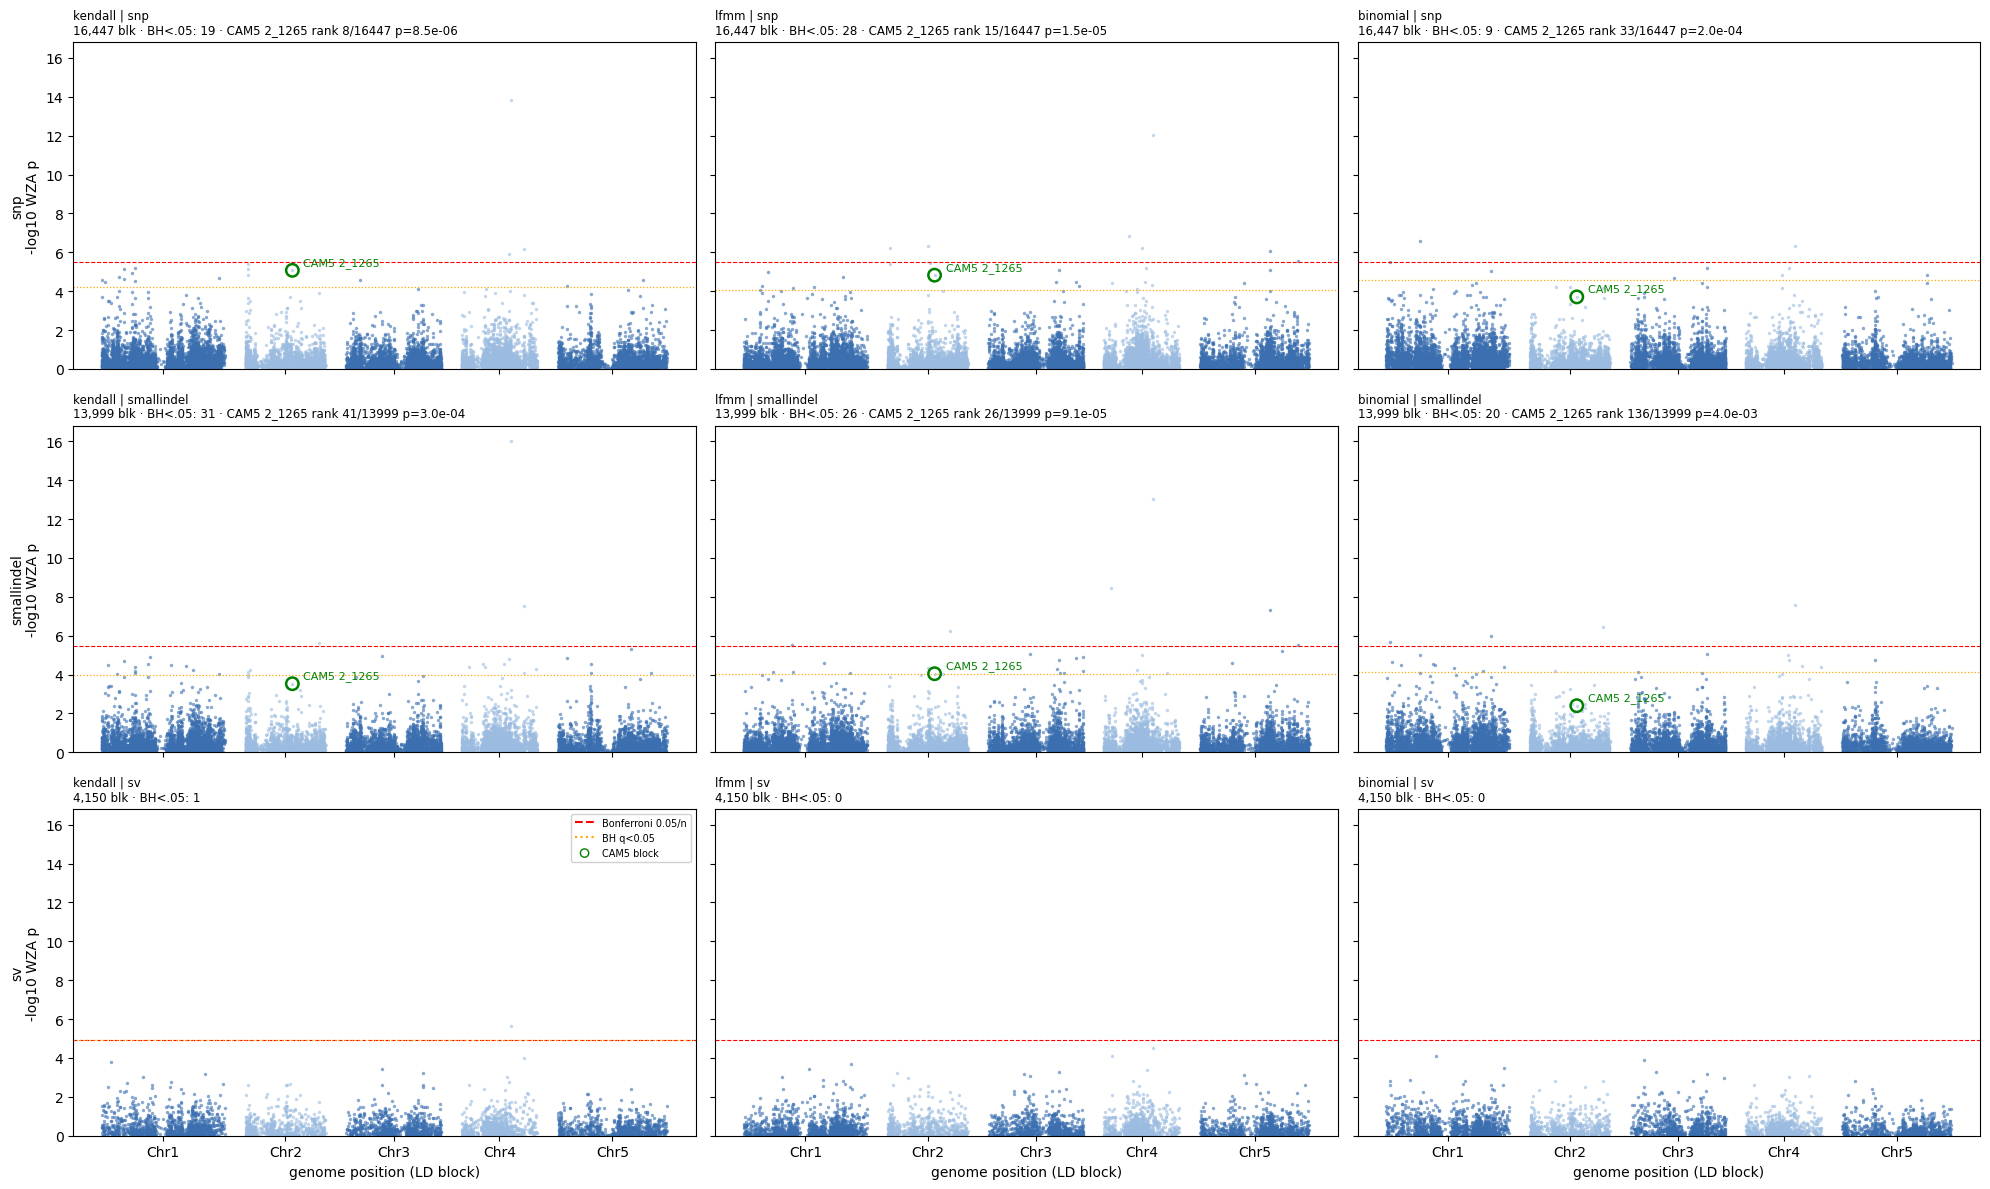

saved /global/scratch/users/tbellg/kmate/analysis/grenenet_gea/r2_gea_nonsnp/phase1_replication/results/manhattan_3models_deg7cap2000.png
saved /global/scratch/users/tbellg/kmate/analysis/grenenet_gea/r2_gea_nonsnp/phase1_replication/results/manhattan_3models_deg7cap2000.pdf


In [2]:
YMAX = -np.log10(Q_FLOOR)       # = 16: the p-floor IS the ceiling; floored blocks sit at top
chrom_col = {c: ("#3b6fb0" if i % 2 == 0 else "#9bbce0") for i, c in enumerate(CHROMS)}

fig, axes = plt.subplots(len(CLASSES), len(MODELS), figsize=(20, 12),
                         sharex=True, sharey=True)
for r, cls in enumerate(CLASSES):
    for cc, model in enumerate(MODELS):
        ax = axes[r, cc]
        w = load(model, cls).copy()
        w["x"] = w["pos"] + w["chrom"].map(offset)
        n = len(w)
        y = w["mlogp"].clip(upper=YMAX)
        ofs = w["mlogp"] > YMAX
        for c in CHROMS:
            m = (w["chrom"] == c) & ~ofs
            ax.scatter(w["x"][m], y[m], s=6, c=chrom_col[c], alpha=.6, linewidths=0,
                       rasterized=True)
        if ofs.any():                                       # off-scale blocks as ^ at top
            ax.scatter(w["x"][ofs], np.full(int(ofs.sum()), YMAX), marker="^", s=35,
                       color="red", edgecolor="k", zorder=6)
        # threshold lines
        bonf = 0.05 / n
        ax.axhline(-np.log10(bonf), color="red", lw=0.8, ls="--")
        nbh, crit = bh_count_crit(w["Z_pVal"])          # BH critical-value line q*k/m
        if nbh:                                          # draw only when >=1 block is BH-significant
            ax.axhline(-np.log10(crit), color="orange", lw=0.9, ls=":")
        # CAM5 mark: snp/smallindel only — no SV is called in the CAM5 block
        if cls != "sv":
            ws = w.sort_values("Z_pVal").reset_index(drop=True)
            cam = ws[ws["block"] == CAM5_BLOCK]
            if len(cam):
                cb = cam.iloc[0]; rank = int(ws.index[ws["block"] == CAM5_BLOCK][0]) + 1
                cy = min(cb["mlogp"], YMAX)
                ax.scatter(cb["x"], cy, s=80, facecolors="none", edgecolors="green",
                           linewidths=1.8, zorder=7)
                ax.annotate(f"CAM5 {CAM5_BLOCK}", (cb["x"], cy), color="green", fontsize=8,
                            xytext=(8, 4), textcoords="offset points", zorder=8)
                camtxt = f" · CAM5 {CAM5_BLOCK} rank {rank}/{n} p={cb['Z_pVal']:.1e}"
            else:
                camtxt = " · CAM5 absent"
        else:
            camtxt = ""                                  # sv: no CAM5 mark
        ax.set_title(f"{model} | {cls}\n{n:,} blk · BH<.05: {nbh}{camtxt}",
                     fontsize=8.5, loc="left")
        if cc == 0:
            ax.set_ylabel(f"{cls}\n-log10 WZA p", fontsize=10)
        ax.set_ylim(0, YMAX + 0.8)
for ax in axes[-1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS)
    ax.set_xlabel("genome position (LD block)")
# legend proxies
axes[-1, 0].plot([], [], color="red", ls="--", label="Bonferroni 0.05/n")
axes[-1, 0].plot([], [], color="orange", ls=":", label="BH q<0.05")
axes[-1, 0].scatter([], [], facecolors="none", edgecolors="green", label="CAM5 block")
axes[-1, 0].legend(fontsize=7, loc="upper right", framealpha=0.9)
fig.tight_layout()
OUT_PNG = ("/global/scratch/users/tbellg/kmate/results/grenenet_gea/"
           "phase1_replication/manhattan_3models_deg7cap2000.png")
OUT_PDF = OUT_PNG[:-4] + ".pdf"
fig.savefig(OUT_PNG, dpi=130, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight"); plt.show()
print("saved", OUT_PNG)
print("saved", OUT_PDF)

## Read-out
- **CAM5 reproduces across all three SNP models** (circled, top row): a clear top-block
  in kendall/lfmm (BH-significant) and top-0.2% in binomial — whose deg-7 p (~2e-4) sits
  on the polynomial-free ground truth (~1.6e-4), i.e. best-calibrated.
- **smallindel** mirrors the SNP signal at CAM5; **sv** is null (no SV is called in the
  CAM5 block, so the sv panels carry no CAM5 mark) — CAM5 was a SNP/indel signal.
- SVs carry essentially no climate signal here: kendall has a single BH block (which also
  beats Bonferroni), lfmm and binomial have none, so the BH line is absent in those panels.
- LFMM (structure-corrected) and Kendall (raw) call more BH blocks than the binomial,
  which is the most conservative after WZA despite its high raw per-SNP precision.

In [3]:
# compact CAM5 + BH table backing the figure
rows = []
for cls in CLASSES:
    for model in MODELS:
        ws = load(model, cls).sort_values("Z_pVal").reset_index(drop=True)
        n = len(ws); k_bh, _ = bh_count_crit(ws["Z_pVal"])
        cb = None
        if cls != "sv":
            cam = ws[ws["block"] == CAM5_BLOCK]
            cb = cam.iloc[0] if len(cam) else None
        rows.append(dict(model=model, cls=cls, n_blocks=n, n_bh=k_bh,
                         cam5_block=CAM5_BLOCK if cb is not None else "-",
                         cam5_rank=(int(ws.index[ws["block"] == CAM5_BLOCK][0]) + 1) if cb is not None else None,
                         cam5_p=cb["Z_pVal"] if cb is not None else None))
pd.DataFrame(rows)

,model,cls,n_blocks,n_bh,cam5_block,cam5_rank,cam5_p
0,kendall,snp,16447,19,2_1265,8.0,0.000009
1,lfmm,snp,16447,28,2_1265,15.0,0.000015
2,binomial,snp,16447,9,2_1265,33.0,0.000197
3,kendall,smallindel,13999,31,2_1265,41.0,0.000296
4,lfmm,smallindel,13999,26,2_1265,26.0,0.000091
5,binomial,smallindel,13999,20,2_1265,136.0,0.003997
6,kendall,sv,4150,1,-,NaN,NaN
7,lfmm,sv,4150,0,-,NaN,NaN
8,binomial,sv,4150,0,-,NaN,NaN
